<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Termodinamica/Termo2_jm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Python 2:  **función de distribución de velocidades de Maxwell-Boltzmann**
<br>

### &nbsp; **Termodinamica:**

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*


<br>

___

<br>

In [ ]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as cte
from operator import itemgetter # ordenar dict

# constantes importantes
k = cte.k_B.value # cte Boltzmann [J/K] = [kg m^2/s^2 K]


<p align="justify"> La función de distribución de velocidades de Maxwell-Boltzmann surge de la mecanica estadistica para gases ideales como una forma de la probabilidad que pueden tomar ciertas velocidades de moleculas o particulas que componen el gas, y esta dada por la expresion:
<br><br>

$$ f(v)=4\pi (\frac{m}{2\pi kT})^{\frac{3}{2}}v^{2} e^{\frac{-mv^{2}}{2kt}} $$
<br>

Donde $v$ es la velocidad (el módulo) de la partícula, $k$ la constante de Boltzmann $k=1.381*10^{-23}$ [J/K], $m$ es la masa de la particula, y $T$[k] es la temperatura temperatura absoluta.

<br><br>

### **Comportamiento con Masa variable**, Temperatura fija TPW
para distintos valores de la masa m de las partículas (varios tipos de gases He, H2, O2, Ni, Ar, vapor de agua, CO, CO2) y de la temperatura, T.

Se crearon funciones para determiar el valor de la distribucion de probabilidad dados los valores de la masa, temperatura y rango de velocidad. Adicionalmente tambien se crearon funciones para obtener la velocidad más probable, la velocidad media y la raíz cuadrada de la velocidad cuadrática media.


In [ ]:
# particulas y masas [kg]
dic = {'He':6.6464731e-27, 'H$_{2}$':2*1.6735575e-27, 'O$_{2}$':2*2.6566962e-26,
       'Ni':9.7462675e-26, 'Ar':6.6335209e-26, 'H$_{2}$0 steam':2.9918257e-26,
       'CO':4.6493427e-26, 'CO$_{2}$':7.3060389e-26, 'N':2.3258671e-26, 'p+':1.67e-27 }

# ordenar de mayor a menor masa
dic_sort = dict(sorted(dic.items(),key=itemgetter(1),reverse=True))
gases = list(dic_sort.keys())
m = np.array(list(dic_sort.values()))


# funcion distribucion maxwell-boltzmann
def distri_MB(m,T,v):
  f = 4*np.pi* (m/(2*np.pi*k*T))**(3/2) *v**2 *np.exp(-m*v**2/(2*k*T))
  return f # [m/s]^-1

# velocidad mas probable
def v_probable(T,m): return np.sqrt(2*k*T/m)

# velocidad media
def v_media(T,m): return np.sqrt(8*k*T/(np.pi*m))

# velocidad cuadratica media
def v_rms(T,m): return np.sqrt(3*k*T/m)

### Comportamiento con **Masa variable**, Temperatura fija TPW

[ 239.9086401   277.09204789  290.79906218  324.92199221  347.35157548
  433.00898514  491.10301993  918.69092596 1294.58251037 1832.76514481]
[ 270.7079115   312.66489421  328.13160358  366.63520695  391.94428143
  488.598318    554.15041659 1036.63170185 1460.77993478 2068.05400759]
[ 293.82687657  339.36706456  356.15466002  397.94654357  425.41706064
  530.32553382  601.47590499 1125.16199996 1585.53329016 2244.66971158]


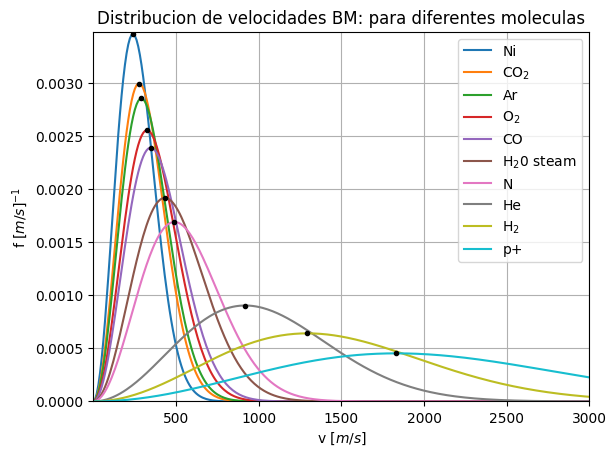

In [ ]:
# definicion parametros
TPW = 273.15-70 # temp fija TPW-70
v = np.linspace(1,3000,300) # rango de velocidades

f_masa_vari = [distri_MB(m[i],TPW,v) for i in range(len(m))] # distribucion
v_prob = v_probable(TPW,m)
v_medi = v_media(TPW,m)
v_rm   = v_rms(TPW,m)


# grafica
for i in range(len(m)):
  plt.plot(v, f_masa_vari[i], label=f'{gases[i]}')
  plt.plot(v_prob[i], max(f_masa_vari[i]), 'k.')
  # plt.vlines(v_medi[i], 0,0.0021 )

plt.title('Distribucion de velocidades BM: para diferentes moleculas')
plt.xlabel('v $[m/s]$')
plt.ylabel('f $[m/s]^{-1}$')
plt.xlim(v[0],v[-1])
plt.ylim(0,max(f_masa_vari[0]+f_masa_vari[-1]))
plt.grid()
plt.legend()

print(v_prob )
print(v_medi )
print(v_rm )


### **Discusión**
<p align="justify">  A medida que la masa aumenta, el valor de la distribucion tambien lo hace, es decir la campana se hace mas alta, y debido a que se trata de una distribucion de probabilidad, el area bajo la curva debe conservarse y sumar 1, por lo que si la campana se estira verticalmente, implica que su ancho disminuirá. Si por el contrario la masa disminuye, el alto de la campana tambien disminuirá haciendo que se haga mas ancha.

<p align="justify">  Se puede concluir entonces que la masa es proporcional (potencial o exponencialmente) al valor de la distribucion. Se puede ver intuitivamente de esta forma, en un gas con particulas livianas cuesta menos trabajo y energia moverlas, por lo que tendran mayor velocidad, a diferencia de particulas pesadas, que requeriran de mayor trabajo para ser movidas. (siempre y cuando se aplique el mismo trabajo en ambos sistemas)

Cabe notar que el ancho de la campana determina un conjunto de velocidades posibles que puede tomar una particula del gas que la compone, por lo que si un gas tiene una campa ancha indica que los valores de velocidad pueden ser mas variados o dispersos, pues un ancho mas grande implica un rango de velocidad mas grande tambien. Un gas con particulas de baja masa se podran encontrar particulas moviendose velocidades muy distintas, mientras que en uno con particuals mas masivas, las velocidades tenderan a ser mas "similares".

#### **Atmosfera terrestre**
* ¿Para los rangos de temperatura de la atmósfera terrestre, cuáles de los gases tienen más probabilidad de escapar de la gravedad del planeta tierra?.

En la **troposfera**, que es la capa atmosferica donde se encuentra el mayor porcentaje de gas atmosferico, suele tener un rango de temperaturas entre -70°c y 15°c.
No obstante, si se tiene en cuenta otras capas como la termosfera, entonces la temperatura puede llegar hasta los 1500 °c.

In [ ]:
T_earth = np.array([-70+273.15, 15+273.15, 1500+273.15])
v = np.linspace(1,8000,300) # rango de velocidades

# vamos a evaluar el anterior codigo para las temperaturas de la atm terrestre
def fun(t):

  f = [distri_MB(m[i],t,v) for i in range(len(m))] # distribucion
  v_prob = v_probable(t,m)
  v_medi = v_media(t,m)
  v_rm   = v_rms(t,m)

  # grafica
  for i in range(len(m)):
    plt.plot(v, f[i])
    plt.plot(v_prob[i], max(f[i]), 'k.')

  plt.title('Distribucion de velocidades BM: temperatura terrestre')
  plt.xlabel('v $[m/s]$')
  plt.ylabel('f $[m/s]^{-1}$')
  plt.grid()

### Temperatura en troposfera (-70°c)

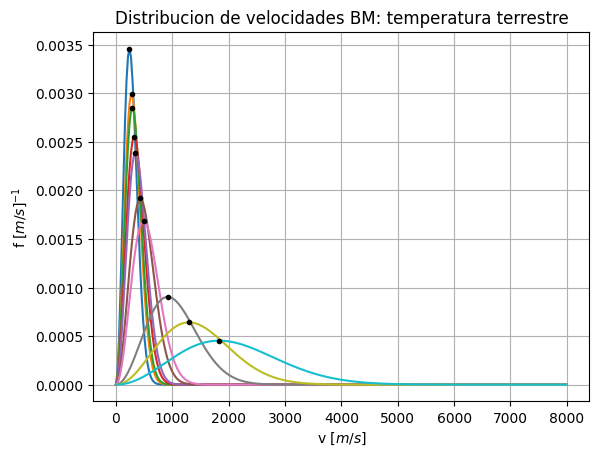

In [ ]:
fun(T_earth[0])

### Temperatura en troposfera (15°c)

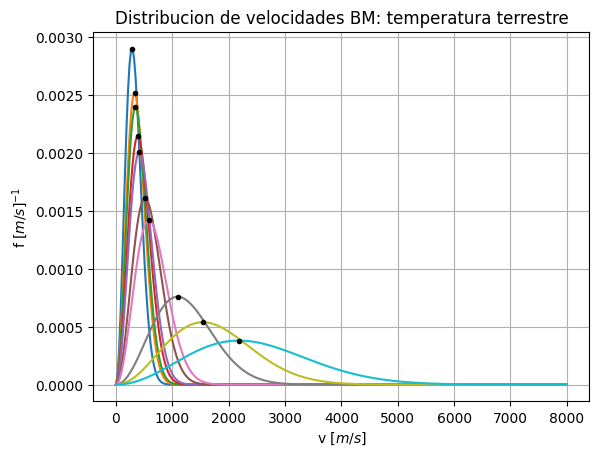

In [ ]:
fun(T_earth[1])

### Temperatura en termosfera 1500°c

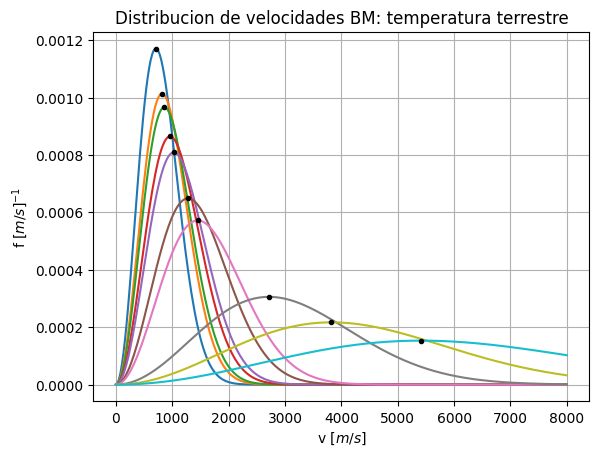

In [ ]:
fun(T_earth[2])

los gases que tendrian mas probabilidad de escapar de la tierrra son los mas livianos, es decir de menor masa como el hidrogeno molecular o el helio. no obstante teniendo en cuenta que la velocidad de escape de la tierra es de 11200 m/s y la velocidad mas alta probable de estos gases es aproximadamente 4000 m/s el caso del hidrogeno molecular, entonces no es muy fatible que se de tal escape

### **Comportamiento con Temperatura variable**, masa fija

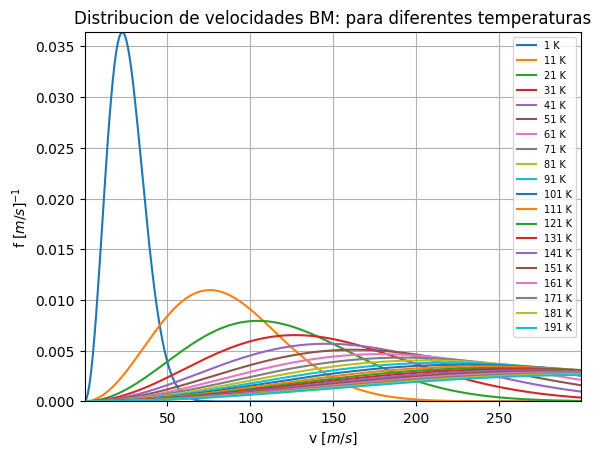

In [ ]:
# definicion parametros
v2 = np.arange(0.1,300,1) # [m/s]
T = np.arange(1,200,10)   # [K]
f_T_vari = [ distri_MB(m[3],T[i],v2) for i in range(len(T)) ]


# grafica
for i in range(len(T)):
  plt.plot(v2, f_T_vari[i], label=f'{T[i]} K')

plt.title('Distribucion de velocidades BM: para diferentes temperaturas')
plt.xlabel('v $[m/s]$')
plt.ylabel('f $[m/s]^{-1}$')
plt.xlim(v2[0],v2[-1])
plt.ylim(0,max(f_T_vari[0]+f_T_vari[-1]))
plt.grid()
plt.legend(fontsize=7)

la variacion de la distribucion respecto a la temperatura es de cierto sentido inverza, mientras la temperatura aumenta, la altura de la distribucion disminuye, su ancho aumenta y la velocidad tambien auenta. mientras que para temperaturas bajas, la altura de la campana aumenta, su ancho disminuye, y el rango de velocidades tambien lo hace. lo que concuerda con la teoria cinetica de los gases.

#### **Otras Atmosferas planetarias**

* ¿Qué ocurriría con estos gases en el planeta marte?.

como la velocidad de escape en marte es de  5050 m/s siendo menor que la terrestre, las particulas de los gases si puede que superen tal velocidad y escapen del planeta rojo. entre sea menor la gravedad del planeta, es mas facil que las particulas de los gases superen la velocidad de escape.


* ¿Cómo es la composición de los gases de las atmosferas de los planetas del sistema solar? </p>


la composicion de la atmosfera terrestre es de mayoritariamente de nitrógeno (78,08%), oxígeno (20,94%), vapor de agua (1-4%), argón (0,93%), el dióxido de carbono (0,04%). la de mercurio oxígeno, sodio, hidrógeno y helio. la de venus casi la totalidad es de dióxido de carbono, seguido de nitrógeno. <br>
Por su parte, los gigantes gaseosos tienen mayormente composicion atmosferica de hidrógeno, helio, sulfuro y nitrógeno.





<br><br>

###**Bibliografia** <br>
 [1] gases del ss. https://descargas.intef.es/cedec/proyectoedia/biologia_geologia/contenidos/investigando_la_atmosfera/los_gases_de_la_atmsfera.html#:~:text=Los%20gases%20que%20integran%20la,%2C0001%25)%2C%20entre%20otros.

 [2] distribucion MB. https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution

 [3] https://es.wikipedia.org/wiki/Atm%C3%B3sfera_terrestre#:~:text=La%20temperatura%20es%20m%C3%A1xima%20en,a%20los%2012%20km%20de


